In [1]:
import logic.pulsed.pulse_objects as po
from logic.pulsed.sampling_functions import SamplingFunctions as SF
import time
import matplotlib.pyplot as plt
import pickle
import datetime
from tqdm import tqdm
from matplotlib.pyplot import cm
import numpy as np
pjl = pulsedjupyterlogic_AWG #Make sure the Logic is started in the Qudi manager!!!!

In [2]:
def setup_autoapproach():
    #configuration of autoapproach settings
    # for HFAmpl signal

    threshold = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_SETP_DISP')) / 1e7
    spm._dev.aap.setAApThreshold(threshold)

    # dF     8
    # HFAmpl       13
    input_signal = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_INPUT'))
    threshold_cond = 1 if input_signal==13 else 0        
    spm._dev.aap.setAApStopCondition(threshold_cond) # [0, 1] >threshold/<threshold
    spm._dev.aap.setAApStepsPerApproach(0)

    spm._dev.aap.setAApAproachMode(1) # [0, 1] Ramp/Loop
    spm._dev.aap.setAApModeAfter(0) # [0, 1, 2] On/Retract/Off

def get_pos(reps=5):
    pos = 0
    for i in range(reps):
        pos = pos+ spm.get_sample_pos()['Z']
        time.sleep(0.005)
    return pos/reps

def go_into_contact():
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_AAP_CTRL'), 1, 0)
    while not spm.is_probe_landed():
        time.sleep(0.001)
    time.sleep(0.5)
        
def do_lift_off(lift_off_height):
    pos = get_pos()
    new_pos = pos - lift_off_height
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_LOOP_ON'), 0, 0)
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_SET_Z_M'), new_pos*1e12, 0)
    
def goto(x_pos, y_pos):
    afm_scanner_logic.set_afm_pos({'x':x_pos, 'y':y_pos})


def get_topo(reps=5):
    topo = 0
    for i in range(reps):
        topo = topo + spm.get_sample_pos()['Z']
        time.sleep(0.005)
    return spm.get_sample_scan_range()['Z'] - topo/reps

#### Define general measurement params

In [5]:
#measurement parameters
laser_power_voltage = podmrlogic.laser_power_voltage

#Driving information for the first LO (SMBV)
target_freq_0 = 2.9386e9
LO_freq_0 = target_freq_0 + 100e6
power_0 = -5
pi_pulse = 46e-9 

#For same NV rabi SGS is run with power_1 = power_0 - 11dBm
#Driving information for the second LO (SGS)
target_freq_1 = 2.87e9
LO_freq_1 = target_freq_1 + 100e6
power_1 = -100
pi_pulse_1 = 72e-9

#Scan area
scan_start_x=11.3e-6
scan_stop_x=12.3e-6
scan_step_x=100

scan_start_y=4.9e-6 
scan_stop_y=6.9e-6
scan_step_y=100

retract = True

switch_MW = False #If True, MW1 is used as the main MW source

#additional information for save tag
tip_name = 'A-H12-13'
sample = 'YCBO'
temperature = '80K'
b_field = '5mT_OOP_FC'
contact = 'IC'
extra = '32.165242kHz_230mV'

#### Load and ready Gradiometry sequence

In [6]:
HF_Ampl_set = 0.640 #None

osc_freq = 32.165242e3
t0 = 0
overhead = 5e-6

max_sweeps = 150000

alternating = False

pjl.initialize_ensemble(laser_power_voltage = laser_power_voltage, pi_pulse=pi_pulse, 
                                pi_pulse_1=pi_pulse_1, LO_freq_0=LO_freq_0, target_freq_0=target_freq_0, 
                                power_0=power_0, LO_freq_1=LO_freq_1, target_freq_1=target_freq_1, power_1=power_1, 
                                switch_MW = switch_MW, trigger_type = 'pos_edge_rearm', trigger_level0 = 400, trigger_level1 = -200)

ret = pjl.Iso_B_multi_gradiometry(osc_freq, t0, overhead)
meas_num = len(ret[2])

scan_array_x = np.linspace(scan_start_x, scan_stop_x, scan_step_x)
scan_array_y = np.linspace(scan_start_y, scan_stop_y, scan_step_y)

topography = np.zeros((scan_step_y,scan_step_x))
Iso_b_data = np.zeros((scan_step_y,scan_step_x, meas_num))
Iso_b_err = np.zeros((scan_step_y,scan_step_x, meas_num))
Iso_b_sweeps = np.zeros((scan_step_y,scan_step_x))

afm_scanner_logic.jupyter_meas_stop = False

meas_dict = {}

for idy, y_pos in enumerate(tqdm(scan_array_y)):
    for idx, x_pos in enumerate(scan_array_x):

        #Move to new pixel position
        goto(x_pos,y_pos)
        #Measure Topography
        topography[idy,idx] = get_topo()

        pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps = 0
        pjl.start_measurement(measurement_type='Iso_B_multi_gradiometry', tip_name=tip_name, sample=sample, 
                              temperature=temperature, b_field=b_field, contact=contact, extra=extra)

        while True and not afm_scanner_logic.jupyter_meas_stop:
            if pulsedmasterlogic_AWG.elapsed_sweeps>max_sweeps:
                pulsedmeasurementlogic_AWG.stop_pulsed_measurement()
                Iso_b_data[idy, idx]  = pulsedmasterlogic_AWG.signal_data[1]
                Iso_b_err[idy, idx]  = pulsedmasterlogic_AWG.measurement_error[1]
                Iso_b_sweeps[idy, idx]  = pulsedmasterlogic_AWG.elapsed_sweeps
                break
            else:
                time.sleep(0.01)

        if afm_scanner_logic.jupyter_meas_stop:
            break



meas_dict = {"topography": topography.copy(), "Iso_b_data": Iso_b_data.copy(), "Iso_b_err": Iso_b_err.copy(), "Iso_b_sweeps": Iso_b_sweeps.copy(), 'Scan_arr_y': scan_array_y, 'Scan_arr_x': scan_array_x }


string = datetime.datetime.now().isoformat('_','seconds')+'_'+'Iso_B_multi_gradiometry'+'_'+tip_name+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)

100%|##################################################################################| 40/40 [2:31:15<00:00, 226.88s/it]
Traceback (most recent call last):
  File "C:\Users\yy3\Documents\Software\qudi\logic\jupyterkernel\qzmqkernel.py", line 679, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-6-fa7d9bf9b45e>", line 55, in <module>
    meas_dict[TF_Amp] = {"topography": topography.copy(), "Iso_b_data": Iso_b_data.copy(), "Iso_b_err": Iso_b_err.copy(), "Iso_b_sweeps": Iso_b_sweeps.copy()}
NameError: name 'TF_Amp' is not defined


In [32]:
meas_dict = {"topography": topography.copy(), "Iso_b_data": Iso_b_data.copy(), "Iso_b_err": Iso_b_err.copy(), "Iso_b_sweeps": Iso_b_sweeps.copy(), 'Scan_arr_y': scan_array_y, 'Scan_arr_x': scan_array_x }


string = datetime.datetime.now().isoformat('_','seconds')+'_'+'Iso_B_multi_gradiometry'+'_'+tip_name+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)

#### Load and ready Gradiometry sequence with lift off

Pickle load

In [33]:
root = r"G:\Data\Qudi_Data\2024\12\20241211\Lock-In-Tip"
path = root +"\\"+ "2024-12-11_09-48-25_Iso_B_multi_gradiometry_A-H12-13_32.165242kHz_230mV" 
with open(path+'.pickle', 'rb') as f:
    data = pickle.load(f)

In [38]:
print(data.keys())
data['Iso_b_data'].shape[2]

9

dict_keys(['topography', 'Iso_b_data', 'Iso_b_err', 'Iso_b_sweeps', 'Scan_arr_y', 'Scan_arr_x'])


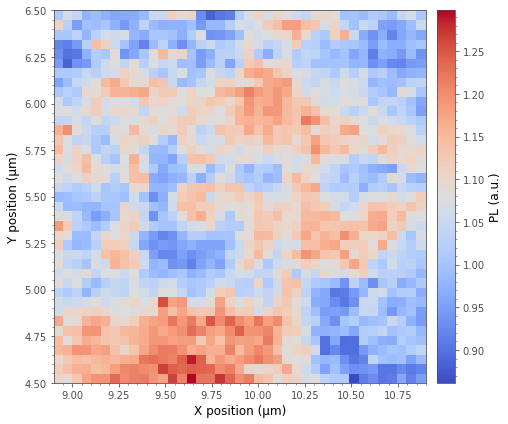

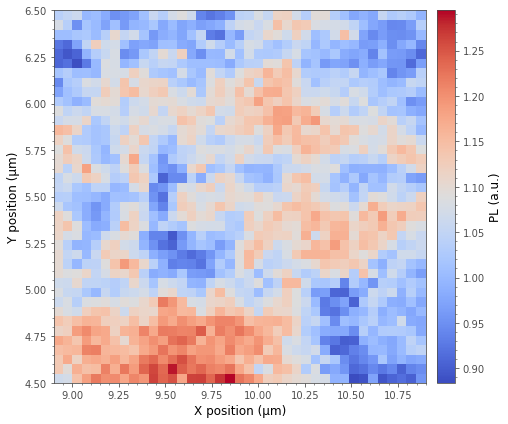

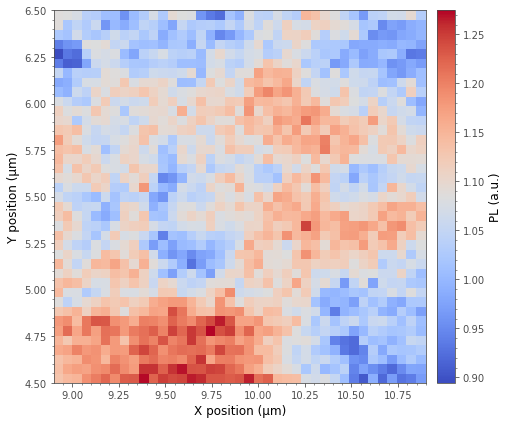

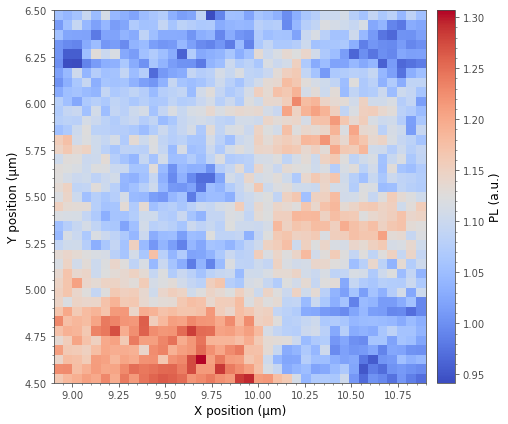

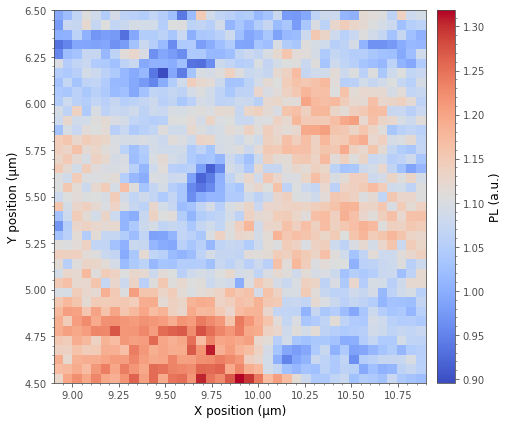

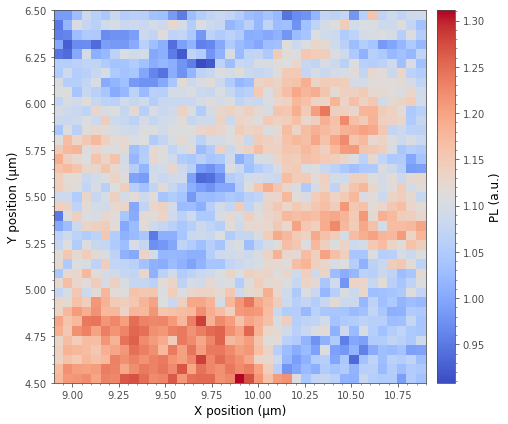

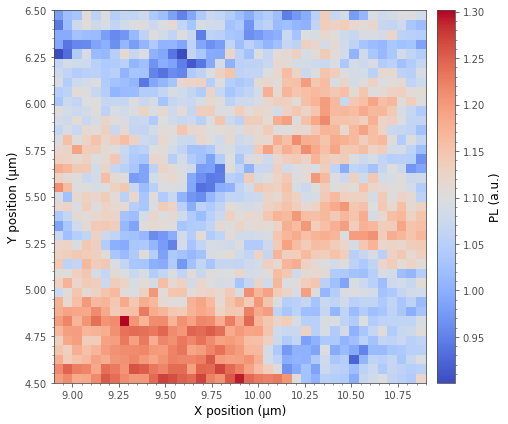

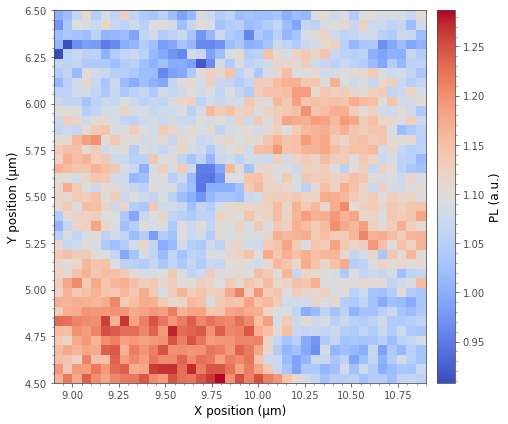

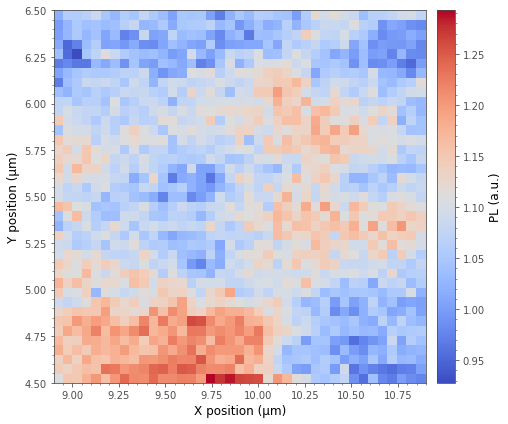

100%|#####################################################################################| 40/40 [05:33<00:00,  8.34s/it]


In [39]:
meas_num = data['Iso_b_data'].shape[2]
for i in range(meas_num):
    data_plot = data['Iso_b_data'][:40,:40,i]
    low_centile = 0
    high_centile = 100
    x =  data['Scan_arr_x']*1e6
    y = data['Scan_arr_y']*1e6

    im = plt.pcolormesh(x,y,data_plot,cmap=plt.cm.get_cmap('coolwarm'), vmin =np.nanpercentile(data_plot, low_centile), vmax = np.nanpercentile(data_plot, high_centile))
    plt.xlabel('X position (\u03BCm)',fontsize = fontsize)
    plt.ylabel('Y position (\u03BCm)',fontsize = fontsize)

    ax = plt.gca()
    ax.set_aspect('equal')

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.15)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label(label='PL (a.u.)', size=fontsize)

    plt.tight_layout()

    plt.show()
